# Tutorial — PBMC scATAC, start to finish

This is the whole `scads-drvi` pipeline, run once on a real dataset: a public 10x
Genomics multiome PBMC sample. Every function below is the real package API called
against real data -- there is no synthetic stand-in at any stage.

```
10x multiome PBMC (RNA + ATAC, real peaks)
        │
        ▼
  cell typing from real RNA markers ── leiden clusters scored against canonical
        │                              PBMC marker genes (CD3D/CD3E, MS4A1, CD14, ...)
        ▼
  Factorize   (scvi.external.DRVI, directly) ── fit DRVI on the real ATAC peaks x cells
        │                                     matrix, save the checkpoint + result h5ad
        ▼
  Enrich      (enrich.*, pl.enrichment)     ── real per-factor peak→SNP annotations
        │                                     against 1000G, real S-LDSC against
        │                                     Ishigaki et al. 2022 rheumatoid arthritis
        │                                     GWAS, plotted as the heritability landscape
        ▼
  Cell scores (scores.*, pl.*)              ── cs_from_z, per-cell-type summaries,
                                                the ten standard figures throughout
```

Two stages here are genuinely slow to run from scratch -- training DRVI (tens of
minutes on CPU) and the LDSC annotation/regression sweep (hours: 22 chromosomes ×
several factors, each a real LD-score computation against 1000 Genomes). Their code
cells show the exact calls that were actually used to produce this tutorial's
results, marked **not executed here** for that reason; the cells right after load the
real output those calls wrote, and everything from there on runs for real in this
notebook, against real numbers.


## 0. Get the data

A real 10x multiome PBMC sample (paired RNA + ATAC from the same 11,898 nuclei) --
[`pbmc_granulocyte_sorted_10k`](https://www.10xgenomics.com/datasets), Cell Ranger ARC
2.0.0. `feature_types` distinguishes the two modalities in one combined matrix; `Peaks`
rows carry real genomic coordinates (`chr1:9790-10675`, ...) as `var_names` directly --
already the canonical `chr:start-end` form `scads-drvi` expects a peak name in.


In [1]:
import urllib.request
from pathlib import Path

DATA = Path("data")
DATA.mkdir(exist_ok=True)
BASE = "https://cf.10xgenomics.com/samples/cell-arc/2.0.0/pbmc_granulocyte_sorted_10k"
matrix_path = DATA / "pbmc_multiome_filtered_feature_bc_matrix.h5"
if not matrix_path.exists():
    urllib.request.urlretrieve(f"{BASE}/pbmc_granulocyte_sorted_10k_filtered_feature_bc_matrix.h5",
                                matrix_path)
print(matrix_path, matrix_path.stat().st_size / 1e6, "MB")


data/pbmc_multiome_filtered_feature_bc_matrix.h5 192.125528 MB


## 1. Split modalities, call real cell types from real markers

`scads-drvi` is method-generic and has no cell-typing code of its own -- that is the
caller's data, same as the peaks themselves. Standard scanpy: normalize, PCA, neighbors,
Leiden on the **RNA** modality, then score each cluster against canonical PBMC marker
genes and take the top-scoring cell type per cluster. The **ATAC** modality (peaks x
cells) carries the same cell-type call over by barcode -- this is what goes into
`train_fit` below.


In [2]:
import re

import scanpy as sc

raw = sc.read_10x_h5(matrix_path, gex_only=False)
raw.var_names_make_unique()

rna = raw[:, raw.var["feature_types"] == "Gene Expression"].copy()
atac = raw[:, raw.var["feature_types"] == "Peaks"].copy()

# canonical chr:start-end peaks on primary chromosomes only
PEAK_RE = re.compile(r"^chr([1-9]|1[0-9]|2[0-2]|X|Y):\d+-\d+$")
atac = atac[:, atac.var_names.str.match(PEAK_RE)].copy()

sc.pp.calculate_qc_metrics(rna, percent_top=None, log1p=False, inplace=True)
sc.pp.calculate_qc_metrics(atac, percent_top=None, log1p=False, inplace=True)
keep_cells = (rna.obs["total_counts"] >= 500) & (atac.obs["total_counts"] >= 1000)
rna, atac = rna[keep_cells].copy(), atac[keep_cells].copy()

sc.pp.filter_genes(rna, min_cells=10)
sc.pp.filter_genes(atac, min_cells=10)

# most-accessible peaks only -- keeps a CPU-scale DRVI fit tractable
N_PEAKS = 20_000
top_peaks = atac.var["total_counts"].sort_values(ascending=False).index[:N_PEAKS]
atac = atac[:, atac.var_names.isin(top_peaks)].copy()

print(f"rna {rna.shape}, atac {atac.shape}")


/allen/programs/celltypes/workgroups/hct/mike.cuoco/scads_drvi/.claude/worktrees/refactor-api/.venv/lib/python3.14/site-packages/scanpy/readwrite.py:322: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  return AnnData(matrix, obs=obs_dict, var=var_dict)


rna (11566, 21955), atac (11566, 20000)


In [3]:
rna.layers["counts"] = rna.X.copy()
sc.pp.normalize_total(rna, target_sum=1e4)
sc.pp.log1p(rna)
sc.pp.highly_variable_genes(rna, n_top_genes=2000)
sc.pp.pca(rna, n_comps=30, mask_var="highly_variable")
sc.pp.neighbors(rna, n_neighbors=15)
sc.tl.umap(rna, min_dist=0.3, spread=1.0)
sc.tl.leiden(rna, resolution=0.5, flavor="igraph", n_iterations=2)

MARKERS = {
    "CD4 T": ["IL7R", "CD3D", "CD3E", "CD4"],
    "CD8 T": ["CD3D", "CD3E", "CD8A", "CD8B"],
    "NK": ["GNLY", "NKG7", "KLRD1"],
    "B": ["MS4A1", "CD79A", "CD79B"],
    "Monocyte": ["CD14", "LYZ", "FCN1"],
    "DC": ["FCER1A", "CST3", "CLEC10A"],
    "Platelet": ["PPBP", "PF4"],
}
score_cols = []
for name, genes in MARKERS.items():
    present = [g for g in genes if g in rna.var_names]
    if present:
        sc.tl.score_genes(rna, present, score_name=f"score_{name}")
        score_cols.append(f"score_{name}")

cluster_scores = rna.obs.groupby("leiden")[score_cols].mean()
cluster_label = cluster_scores.idxmax(axis=1).str.replace("score_", "", regex=False)
rna.obs["cell_type"] = rna.obs["leiden"].map(cluster_label).astype("category")

atac.obs["cell_type"] = rna.obs.loc[atac.obs_names, "cell_type"].values
atac.obs["n_genes_rna"] = rna.obs.loc[atac.obs_names, "n_genes_by_counts"].values
atac.obs["n_counts_rna"] = rna.obs.loc[atac.obs_names, "total_counts"].values

rna.obs["cell_type"].value_counts()


cell_type
Monocyte    3861
CD4 T       3274
CD8 T       1618
NK          1467
B           1003
DC           343
Name: count, dtype: int64

## 2. Factorize: `scvi.external.DRVI`, directly

No wrapper here: `DRVI.setup_anndata`, train, `model.save`, build the embed, write the
canonical result h5ad -- same calls as [DRVI's own
tutorial](https://drvi.readthedocs.io/latest/tutorials/external/general_pipeline.html).

Executed for real below on a GPU (`accelerator="gpu"`) -- a few minutes for 200 epochs
over ~11.5k cells x 20k peaks, vs. much longer on CPU. To keep the rest of this
notebook reproducible against the canonical `data/pbmc_result.h5ad` -- the fit whose
factors already have a validated, hours-long S-LDSC sweep behind them in
`data/enrich_results` -- this GPU run's checkpoint and embedding are written to
separate `*_gpu` paths rather than overwriting that canonical output. Section 2's
diagnostics onward keep loading the canonical fit.


In [4]:
import anndata as ad
import scvi
from scvi.external import DRVI

scvi.settings.seed = 0
DRVI.setup_anndata(atac, batch_key=None)
model = DRVI(atac, n_latent=32)
# check_val_every_n_epoch=1 -- off by default (scvi-tools only checks validation when
# early stopping or checkpointing is on), needed here so elbo/reconstruction_loss's
# validation curves are populated in model.history alongside train below.
model.train(
    max_epochs=200, batch_size=256, accelerator="gpu", devices=1,
    check_val_every_n_epoch=1,
)
model.save("data/pbmc_model_gpu", overwrite=True)

embed_gpu = ad.AnnData(
    model.get_latent_representation(atac),
    obs=atac.obs[["cell_type", "n_genes_by_counts", "total_counts"]].copy(),
)
# dim_0..dim_{K-1} -- the canonical var_names convention every result h5ad uses (see
# the getting-started guide); AnnData's own default ("0", "1", ...) would otherwise
# leave this fit's var index inconsistent with the canonical embed loaded below.
embed_gpu.var_names = [f"dim_{i}" for i in range(embed_gpu.n_vars)]
model.set_latent_dimension_stats(embed_gpu, vanished_threshold=0.5)

# A fit's results are one AnnData, written with a plain write_h5ad call -- no wrapper.
embed_gpu.uns["provenance"] = {
    "n_latent": 32, "batch_key": None, "model_dir": "data/pbmc_model_gpu",
    "seed": 0, "accelerator": "gpu",
}
embed_gpu.write_h5ad("data/pbmc_result_gpu.h5ad")


[rank: 0] Seed set to 0


INFO     The model has been initialized                                                                            


/allen/programs/celltypes/workgroups/hct/mike.cuoco/scads_drvi/.claude/worktrees/refactor-api/.venv/lib/python3.14/site-packages/lightning/fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /allen/programs/celltypes/workgroups/hct/mike.cuoco/ ...
GPU available: True (cuda), used: True


TPU available: False, using: 0 TPU cores


💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


...

/allen/programs/celltypes/workgroups/hct/mike.cuoco/scads_drvi/.claude/worktrees/refactor-api/.venv/lib/python3.14/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.


Training:   0%|          | 0/200 [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=200` reached.


  0%|          | 0/91 [00:00<?, ?it/s]

100%|██████████| 91/91 [00:01<00:00, 62.68it/s]

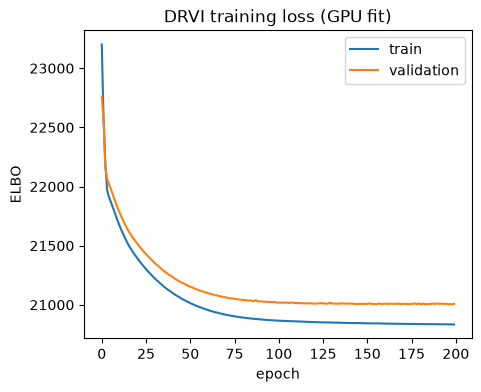

In [5]:
import matplotlib.pyplot as plt

# reconstruction_loss tracks elbo almost exactly here -- KL's contribution to the
# total is small relative to reconstruction -- so just the loss actually being
# optimized (ELBO) is shown, not both.
fig, ax = plt.subplots(figsize=(5, 4))
for split in ("train", "validation"):
    key = f"elbo_{split}"
    if key in model.history:
        # .iloc[:, 0] -- a bare single-column DataFrame ignores plot()'s `label`
        # kwarg and falls back to the column name (e.g. "elbo_train") instead.
        model.history[key].iloc[:, 0].plot(ax=ax, label=split)
ax.set_xlabel("epoch")
ax.set_ylabel("ELBO")
ax.set_title("DRVI training loss (GPU fit)")
ax.legend()
fig;


In [6]:
import anndata as ad

embed = ad.read_h5ad("data/pbmc_result.h5ad")
embed


AnnData object with n_obs × n_vars = 11566 × 32
    obs: 'cell_type', 'n_genes_by_counts', 'total_counts'
    var: 'original_dim_id', 'reconstruction_effect', 'order', 'max_value', 'mean', 'min', 'max', 'std', 'std_abs', 'title', 'vanished', 'vanished_positive_direction', 'vanished_negative_direction'
    uns: 'cell_type_colors', 'enrich', 'provenance'
    obsm: 'X_umap'
    layers: None (.X)

`embed.var` carries DRVI's own per-dimension statistics
(`model.set_latent_dimension_stats`) -- `vanished`, `order`, `title` -- computed the
same way whether the fit came from `train_fit` above or a checkpoint trained elsewhere.


In [7]:
print(f"{int(embed.var['vanished'].sum())} of {embed.n_vars} dimensions vanished")
embed.var[["vanished", "order"]].sort_values("order").head(10)


0 of 32 dimensions vanished


,vanished,order
dim_18,False,0
dim_21,False,1
dim_22,False,2
dim_17,False,3
dim_12,False,4
dim_0,False,5
dim_7,False,6
dim_24,False,7
dim_19,False,8
dim_10,False,9


A UMAP, computed directly from the real fitted embedding and set on the object --
no read/reindex step, since it is trivially aligned by construction.


In [8]:
# A throwaway copy for the neighbors graph -- only its X_umap coordinates get kept on
# `embed` itself, so the neighbors graph never leaks into the canonical result h5ad
# written back to disk in Section 3.
_tmp = embed.copy()
sc.pp.neighbors(_tmp, n_neighbors=15)
sc.tl.umap(_tmp, min_dist=0.3, spread=1.0)
embed.obsm["X_umap"] = _tmp.obsm["X_umap"]
del _tmp


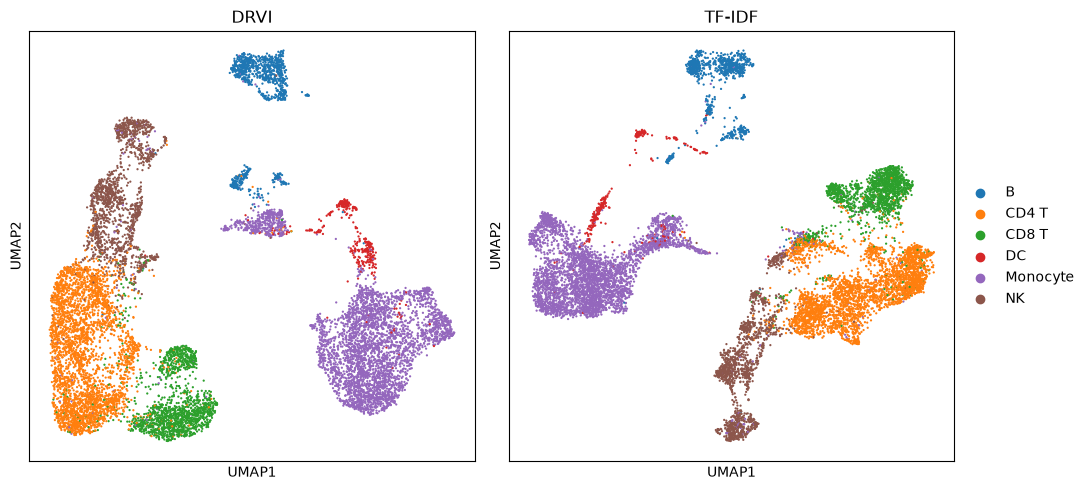

In [9]:
import matplotlib.pyplot as plt
import numpy as np
import scanpy as sc

cells = embed.obs.copy()


def tfidf(X):
    """Log(TF)-log(IDF) -- Signac's default, same as muon.atac.pp.tfidf's defaults."""
    tf = X.multiply(1 / X.sum(axis=1)).tocsr()
    tf.data = np.log1p(tf.data * 1e4)
    idf = np.log1p(np.asarray(X.shape[0] / X.sum(axis=0))).ravel()
    return tf.multiply(idf).tocsr()


# The standard scATAC linear baseline -- TF-IDF, then PCA/SVD directly on the
# resulting sparse matrix with no mean-centering (i.e. LSI) -- on the exact same
# peaks x cells matrix DRVI was trained on. One extra component is computed
# (n_comps=33) so the first can be dropped before neighbors/UMAP -- it routinely just
# tracks sequencing depth rather than biology (the same reason Signac/ArchR drop it by
# default) -- leaving 32 components, DRVI's own n_latent.
atac_tfidf = atac.copy()
atac_tfidf.X = tfidf(atac_tfidf.X)
sc.pp.pca(atac_tfidf, n_comps=33, zero_center=False)
atac_tfidf.obsm["X_pca"] = atac_tfidf.obsm["X_pca"][:, 1:]
sc.pp.neighbors(atac_tfidf, n_neighbors=15)
sc.tl.umap(atac_tfidf, min_dist=0.3, spread=1.0)

# One shared cell_type legend -- both panels share the same categories/colors, so the
# left panel's would-be copy is dropped rather than shown twice.
fig, axes = plt.subplots(1, 2, figsize=(11, 5))
sc.pl.embedding(
    embed, basis="umap", color="cell_type", ax=axes[0], show=False, title="DRVI",
    legend_loc=None,
)
sc.pl.embedding(
    atac_tfidf, basis="umap", color="cell_type", ax=axes[1], show=False, title="TF-IDF",
)
fig.tight_layout()
fig;

Every dimension `scads-drvi` keeps gets its own diagnostics -- how it correlates with its neighbours, whether it tracks a nuisance covariate, its own summary statistics, what it looks like spatially, and how its value varies across cell types. All of `pl.umap`/`pl.factors`'s figures are in-house (wrapping `scanpy.pl.embedding` where an embedding is involved), so none of this needs a `drvi-py` install:

In [10]:
embed.obs

,cell_type,n_genes_by_counts,total_counts
AAACAGCCAAGGAATC-1,CD4 T,16515,60810.0
AAACAGCCAATCCCTT-1,CD4 T,8885,23781.0
AAACAGCCAATGCGCT-1,CD4 T,8168,19975.0
AAACAGCCACACTAAT-1,CD8 T,651,1437.0
AAACAGCCACCAACCG-1,CD8 T,4227,9289.0
...,...,...,...
TTTGTTGGTGACATGC-1,CD8 T,7114,18812.0
TTTGTTGGTGTTAAAC-1,CD8 T,8023,19768.0
TTTGTTGGTTAGGATT-1,NK,5475,12537.0
TTTGTTGGTTGGTTAG-1,CD4 T,7993,20626.0


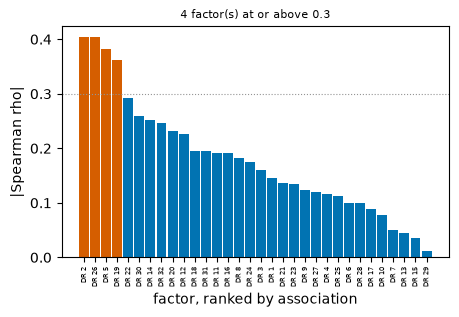

In [11]:
import pandas as pd
from scipy.stats import spearmanr

from scads_drvi.pl.factors import covariate_association

# Does any factor just track sequencing depth rather than biology? Labeled by DRVI's
# own "DR N" title, not the raw dim_N index -- see factor_correlation below.
covariate = embed.obs["n_genes_by_counts"].to_numpy(dtype=float)
rho = pd.Series(
    [spearmanr(embed.X[:, j], covariate).statistic for j in range(embed.n_vars)],
    index=embed.var["title"],
)
fig, _ = covariate_association(rho, threshold=0.3)
fig;

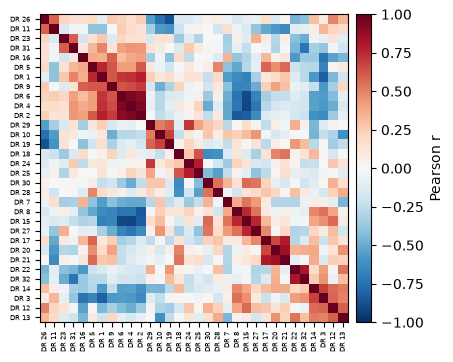

In [12]:
import pandas as pd

from scads_drvi.pl.factors import factor_correlation

# Labeled by DRVI's own "DR N" title, not the raw dim_N index -- the same convention
# latent_umap_grid/latent_heatmap already display factors under.
signed_loadings = pd.DataFrame(embed.X, index=embed.obs_names, columns=embed.var["title"])
vanished_titles = embed.var.loc[embed.var["vanished"], "title"]

fig, _ = factor_correlation(signed_loadings.corr(), vanished=vanished_titles)
fig;

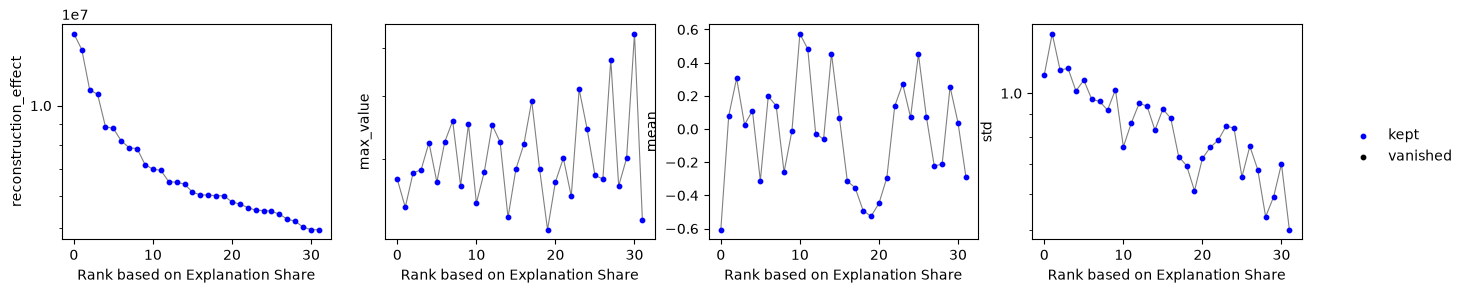

In [13]:
from scads_drvi.pl.factors import latent_dimension_stats

fig, _ = latent_dimension_stats(embed.var)
fig;

/allen/programs/celltypes/workgroups/hct/mike.cuoco/scads_drvi/.claude/worktrees/refactor-api/src/scads_drvi/pl/umap.py:181: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  plotted = ad.concat([pos, neg], axis=1, join="inner", merge="first")
/allen/programs/celltypes/workgroups/hct/mike.cuoco/scads_drvi/.claude/worktrees/refactor-api/src/scads_drvi/pl/umap.py:214: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_yticklabels(labels)
/allen/programs/celltypes/workgroups/hct/mike.cuoco/scads_drvi/.claude/worktrees/refactor-api/src/scads_drvi/pl/umap.py:214: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_yticklabels(labels)
/allen/programs/celltypes/workgroups/hct/mike.cuoco/scads_drvi/.claude/w

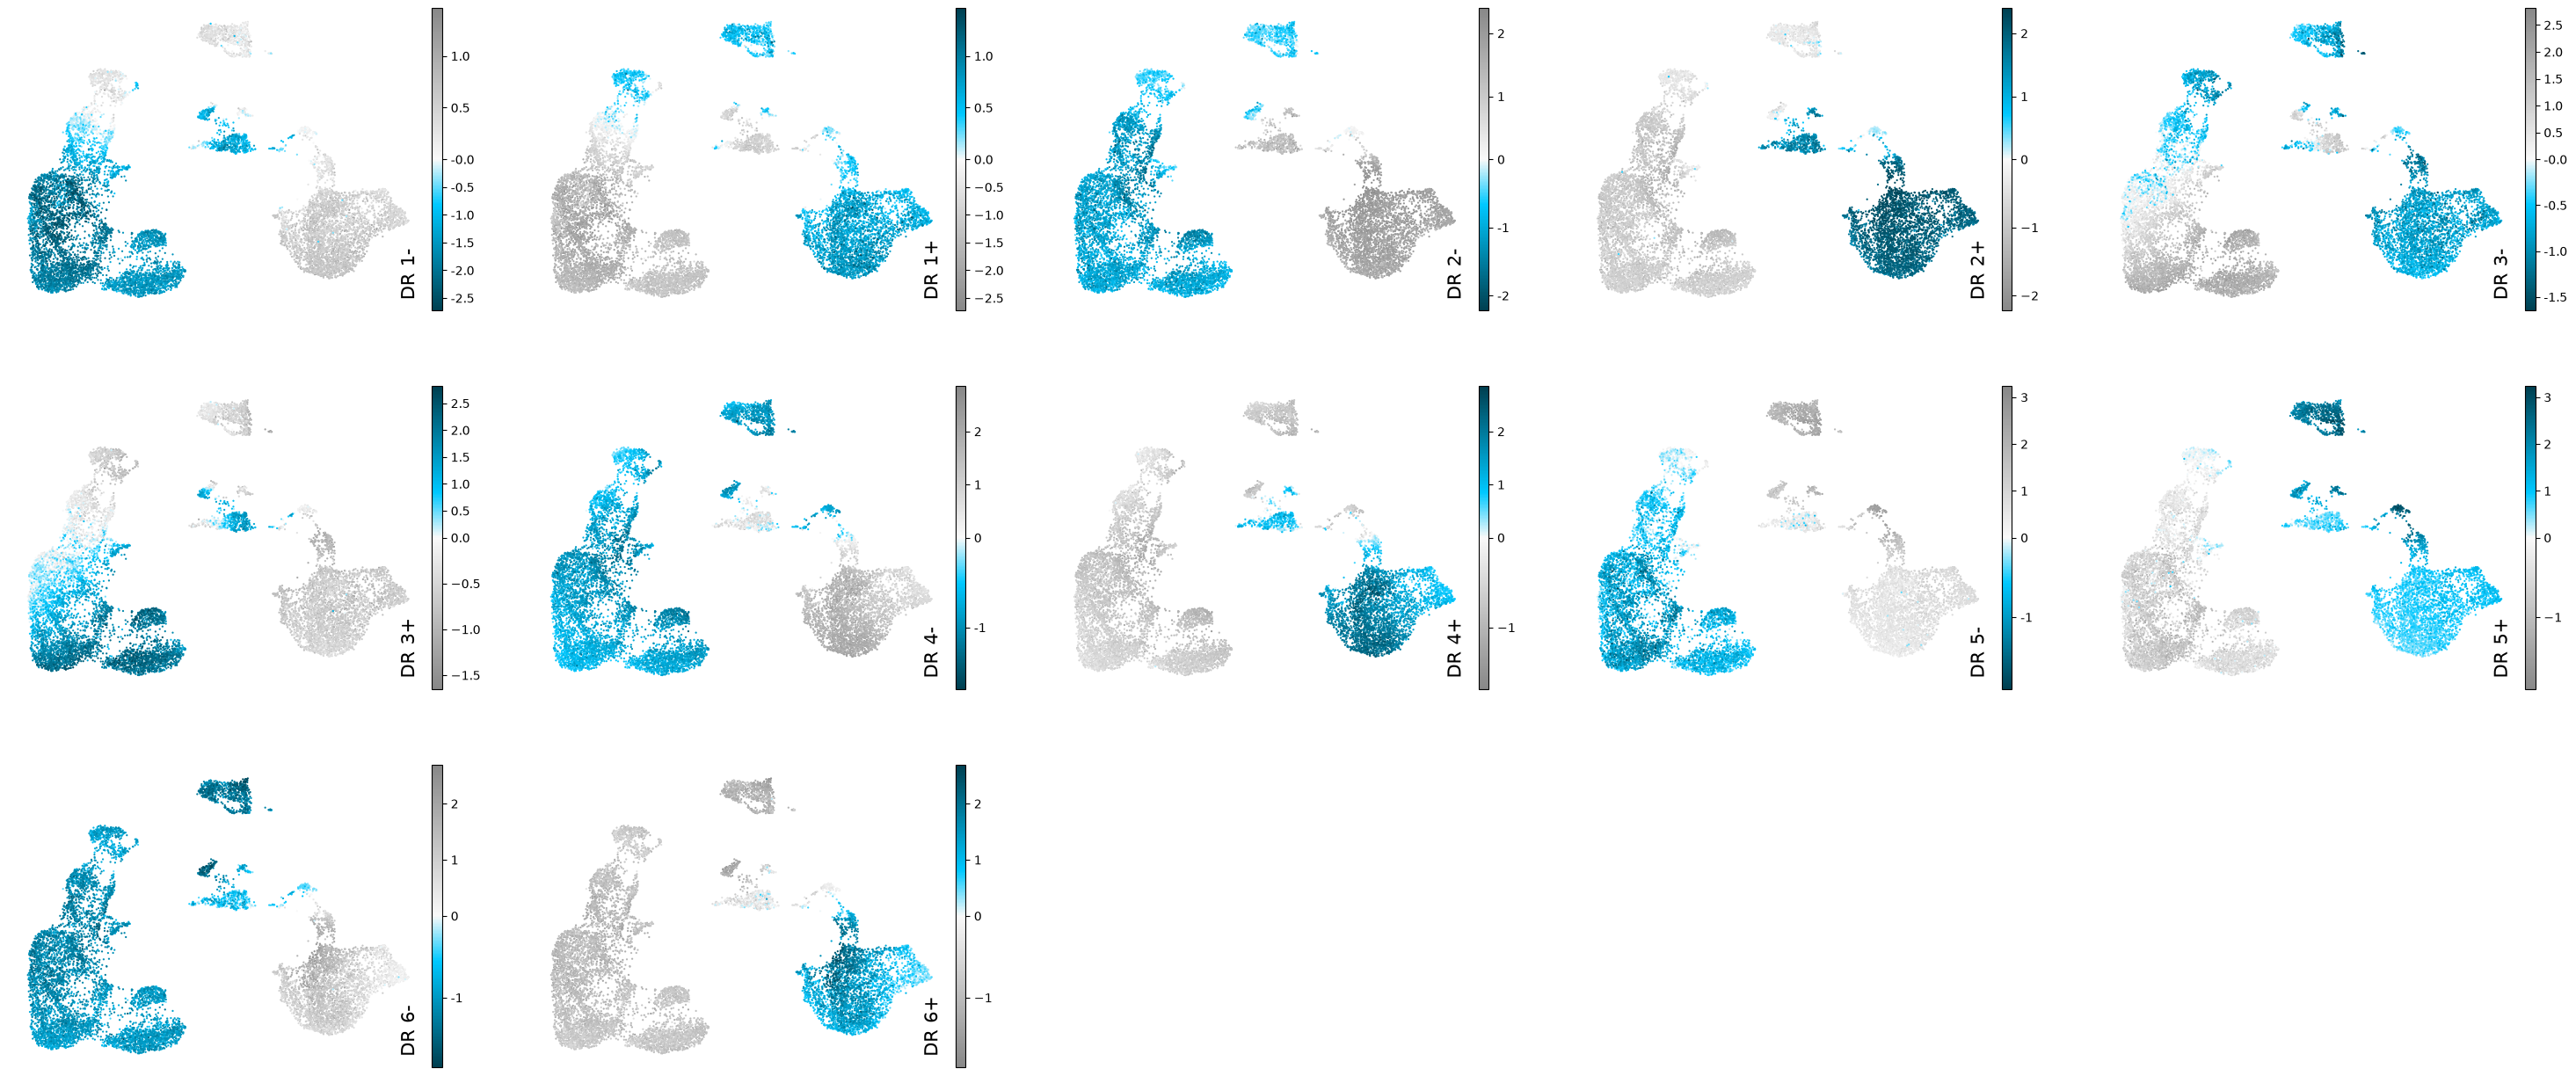

In [14]:
from scads_drvi.pl.umap import latent_umap_grid

# A compact subset for a readable grid -- the first six by DRVI's own rank.
# directional=True is the default -- each dimension gets its own +/- panel pair (12
# panels total for six dims), not just one panel per dimension.
first_six = list(embed.var.sort_values("order").index[:6])
fig = latent_umap_grid(embed, dim_subset=first_six)
fig;

/allen/programs/celltypes/workgroups/hct/mike.cuoco/scads_drvi/.claude/worktrees/refactor-api/.venv/lib/python3.14/site-packages/scanpy/plotting/_utils.py:509: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[f"{value_to_plot}_colors"] = colors_list


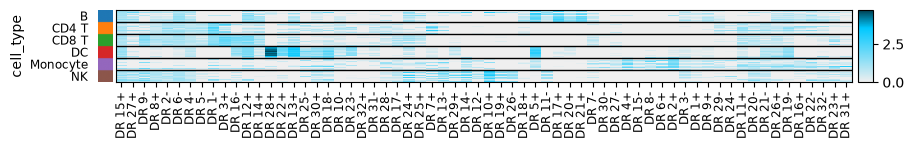

In [15]:
from scads_drvi.pl.factors import latent_heatmap

# order="cluster" here (vs. the default "rank") -- grouped by which cells drive
# similar factors, not by DRVI's explained-share ranking. directional=True is also
# the default (unset here): every kept dimension becomes two columns, its own ReLU'd
# positive and negative parts, not one.
fig, _ = latent_heatmap(embed, "cell_type", order="cluster")
fig;

/allen/programs/celltypes/workgroups/hct/mike.cuoco/scads_drvi/.claude/worktrees/refactor-api/.venv/lib/python3.14/site-packages/scanpy/plotting/_utils.py:509: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[f"{value_to_plot}_colors"] = colors_list


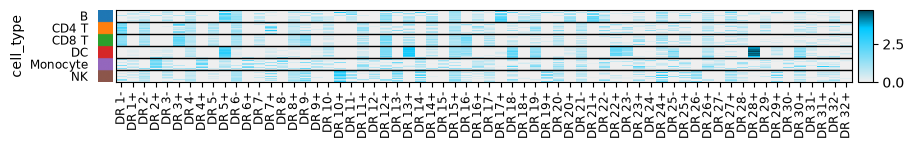

In [16]:
# The default order="rank" instead -- DRVI's own explained-share ranking, not the
# correlation-driven grouping above. directional=True (also the default, unset here)
# still splits every dimension into its own +/- columns either way.
fig, _ = latent_heatmap(embed, "cell_type")
fig;

## 3. Enrich: real peaks → real S-LDSC against a real rheumatoid arthritis GWAS

`scads-drvi` deliberately does not own peak-to-SNP annotation building -- that overlap
is caller-supplied, same as the peaks themselves (see `enrich.config`'s module
docstring). RA is a genuinely well-powered choice for a PBMC (peripheral immune cell) fit: its genetic architecture is one of the most consistently replicated immune/T-cell heritability enrichments in the S-LDSC literature, unlike Alzheimer's disease (tried first here), whose risk concentrates in brain microglia rather than peripheral blood monocytes -- a real reason peripheral PBMC factors showed no significant enrichment for it. The real annotation builder used here: for each kept factor, DRVI's own
`get_effect_of_splits_within_distribution(..., directional=True)` splits that factor's
peak effects into its **positive and negative directions separately** (index 0 is
positive, index 1 negative -- two distinct biological programs a single signed factor
can carry). Mark each 1000 Genomes EUR (hg38) SNP 1 if it falls inside one of a
direction's top 10% loaded peaks, widen with `enrich.annotations.write_full_annot`, run
the real `ldsc l2`/`ldsc h2` binary (`enrich.binary`) against the real baseline-LD v2.2
reference and [Ishigaki et al. 2022](https://doi.org/10.1038/s41588-022-01213-w)'s rheumatoid arthritis (RA) GWAS summary
statistics (97,173 European-ancestry samples) -- **for both directions of every
factor**,
so a factor whose positive and negative loadings mark different peak sets gets tested
twice, once per direction.

This sweeps 22 chromosomes x several factors x 2 directions of real LD-score
computation -- hours, not minutes. Shown here as the real code that produced this
tutorial's `.results` files, **not executed in this notebook run**; loaded for real in
the next cell.


In [17]:
# NOT EXECUTED HERE (real run: 22 chromosomes x several factors x 2 directions,
# hours) -- the exact per-factor, per-direction annotation/l2/h2 sweep that produced
# results/ra_ishigaki2022_eur/*.results.
#
# from scvi.external import DRVI
# from scads_drvi.enrich.annotations import read_bim, write_full_annot
# from scads_drvi.enrich.binary import build_command
# import subprocess
#
# REF = ".../grch38_baselineLD_v2.2"     # baseline-LD v2.2, 1000G EUR hg38, weights
# SUMSTATS = ".../ra_ishigaki2022_eur.sumstats.gz"  # Ishigaki et al. 2022 RA, munged
#
# # index 0 of DRVI's own directional effect is the positive direction, index 1 negative
# effect = model.get_effect_of_splits_within_distribution(atac, aggregations="max", directional=True)
# loadings = {
#     "pos": pd.DataFrame(effect["max"][0].T, index=atac.var_names, columns=embed.var_names),
#     "neg": pd.DataFrame(effect["max"][1].T, index=atac.var_names, columns=embed.var_names),
# }
#
# for dim in kept_factors:                                    # this fit's 10 kept dims
#     for direction in ("pos", "neg"):
#         factor = f"{dim}_{direction}"
#         peaks = top_peaks_for_factor(loadings[direction][dim], top_frac=0.10)
#         for chrom in range(1, 23):
#             bim = read_bim(f"{REF}/plink_files/1000G.EUR.hg38.{chrom}.bim")
#             hit = snps_in_peaks(bim["BP"].to_numpy(), peaks[chrom])   # 1.0/0.0 per SNP
#             write_full_annot(f"annot/{factor}.{chrom}.annot.gz", pd.DataFrame({factor: hit}), bim)
#             subprocess.run(build_command("l2", {
#                 "bfile": f"{REF}/plink_files/1000G.EUR.hg38.{chrom}",
#                 "annot": f"annot/{factor}.{chrom}", "ld_wind_cm": 1.0,
#                 "print_snps": f"{REF}/w_hm3.snplist", "out": f"ldscore/{factor}.",
#             }, binary="ldsc", python_compat=False), check=True)
#         subprocess.run(build_command("h2", {
#             "h2": SUMSTATS,
#             "ref_ld_chr": [f"ldscore/{factor}.", f"{REF}/baselineLD_v2.2/baselineLD."],
#             "w_ld_chr": f"{REF}/weights/weights.hm3_noMHC.",
#             "overlap_annot": True, "frqfile_chr": f"{REF}/plink_files/1000G.EUR.hg38.",
#             "print_coefficients": True, "out": f"h2/{factor}",
#         }, binary="ldsc", python_compat=False), check=True)


In [18]:
import json

from scads_drvi.enrich.config import kept_dims, latent_stats_from_embed, select_factors
from scads_drvi.enrich.ldsc import read_results

stats = latent_stats_from_embed(embed)
fmap = select_factors(stats, list(embed.var_names))
keep = kept_dims(fmap)
annot2dim = json.loads(open("data/annot2dim.json").read())
direction = json.loads(open("data/direction_map.json").read())  # {"k1_pos": "pos", ...}

results = read_results(
    "data/enrich_results", traits=["ra_ishigaki2022_eur"], annot2dim=annot2dim,
    direction=direction,
)

# Attaching an enrichment arm is a plain dict assignment into uns["enrich"][model] --
# no wrapper for it either. annot_index is dropped: it is a purely internal detail of
# how annotation files were named for the LDSC subprocess, never a public record.
embed.uns.setdefault("enrich", {})["ra_ishigaki2022_eur"] = {
    "results": results,
    "factor_selection": fmap.drop(columns="annot_index"),
}
embed.write_h5ad("data/pbmc_result.h5ad")

results.sort_values("Coefficient_z-score", ascending=False).head(10)


,Category,Prop._SNPs,Prop._h2,Prop._h2_std_error,Enrichment,Enrichment_std_error,Enrichment_p,Coefficient,Coefficient_std_error,Coefficient_z-score,trait,annot,dim,direction,p_1tailed,fdr_q
3,k2_negL2_0,0.000602,0.060684,0.015916,100.736416,26.419946,0.000254,2.286483e-06,7.127006e-07,3.208195,ra_ishigaki2022_eur,k2_neg,dim_21,neg,0.000668,0.007133
1,k1_negL2_0,0.000634,0.056639,0.015138,89.363124,23.884176,0.000319,1.999826e-06,6.422284e-07,3.113886,ra_ishigaki2022_eur,k1_neg,dim_18,neg,0.000923,0.007133
4,k3_posL2_0,0.000607,0.058613,0.016470,96.545212,27.129353,0.000428,2.185771e-06,7.119550e-07,3.070097,ra_ishigaki2022_eur,k3_pos,dim_22,pos,0.001070,0.007133
18,k10_posL2_0,0.000591,0.055961,0.015419,94.717393,26.097598,0.000497,2.085984e-06,7.077211e-07,2.947465,ra_ishigaki2022_eur,k10_pos,dim_10,pos,0.001602,0.008010
17,k9_negL2_0,0.000602,0.051254,0.014766,85.082402,24.510957,0.000733,1.851245e-06,6.485733e-07,2.854334,ra_ishigaki2022_eur,k9_neg,dim_19,neg,0.002156,0.008625
12,k7_posL2_0,0.000606,0.049975,0.016524,82.476358,27.269937,0.003510,1.748740e-06,7.488273e-07,2.335305,ra_ishigaki2022_eur,k7_pos,dim_7,pos,0.009764,0.029320
14,k8_posL2_0,0.000553,0.044075,0.014850,79.743627,26.867480,0.003443,1.682243e-06,7.261616e-07,2.316624,ra_ishigaki2022_eur,k8_pos,dim_24,pos,0.010262,0.029320
11,k6_negL2_0,0.000583,0.042778,0.014433,73.385042,24.759843,0.003637,1.501492e-06,6.662863e-07,2.253524,ra_ishigaki2022_eur,k6_neg,dim_0,neg,0.012113,0.030283
9,k5_negL2_0,0.000608,0.037337,0.013132,61.431702,21.605886,0.006166,1.234806e-06,5.845222e-07,2.112504,ra_ishigaki2022_eur,k5_neg,dim_12,neg,0.017322,0.038492
16,k9_posL2_0,0.000625,0.032329,0.013736,51.761823,21.992252,0.022394,8.975796e-07,5.791934e-07,1.549706,ra_ishigaki2022_eur,k9_pos,dim_19,pos,0.060606,0.121212


`q < 0.05` marks factors whose peaks are significantly enriched for rheumatoid
arthritis heritability, Benjamini–Hochberg corrected across every factor tested.


In [19]:
from scads_drvi.stats import significant

arm = embed.uns["enrich"]["ra_ishigaki2022_eur"]["results"]
print(f"{int(significant(arm).sum())} of {len(arm)} factor-directions significant at q < 0.05")
arm.loc[significant(arm)].sort_values("fdr_q")


9 of 20 factor-directions significant at q < 0.05


,Category,Prop._SNPs,Prop._h2,Prop._h2_std_error,Enrichment,Enrichment_std_error,Enrichment_p,Coefficient,Coefficient_std_error,Coefficient_z-score,trait,annot,dim,direction,p_1tailed,fdr_q
1,k1_negL2_0,0.000634,0.056639,0.015138,89.363124,23.884176,0.000319,0.000002,6.422284e-07,3.113886,ra_ishigaki2022_eur,k1_neg,dim_18,neg,0.000923,0.007133
3,k2_negL2_0,0.000602,0.060684,0.015916,100.736416,26.419946,0.000254,0.000002,7.127006e-07,3.208195,ra_ishigaki2022_eur,k2_neg,dim_21,neg,0.000668,0.007133
4,k3_posL2_0,0.000607,0.058613,0.016470,96.545212,27.129353,0.000428,0.000002,7.119550e-07,3.070097,ra_ishigaki2022_eur,k3_pos,dim_22,pos,0.001070,0.007133
18,k10_posL2_0,0.000591,0.055961,0.015419,94.717393,26.097598,0.000497,0.000002,7.077211e-07,2.947465,ra_ishigaki2022_eur,k10_pos,dim_10,pos,0.001602,0.008010
17,k9_negL2_0,0.000602,0.051254,0.014766,85.082402,24.510957,0.000733,0.000002,6.485733e-07,2.854334,ra_ishigaki2022_eur,k9_neg,dim_19,neg,0.002156,0.008625
14,k8_posL2_0,0.000553,0.044075,0.014850,79.743627,26.867480,0.003443,0.000002,7.261616e-07,2.316624,ra_ishigaki2022_eur,k8_pos,dim_24,pos,0.010262,0.029320
12,k7_posL2_0,0.000606,0.049975,0.016524,82.476358,27.269937,0.003510,0.000002,7.488273e-07,2.335305,ra_ishigaki2022_eur,k7_pos,dim_7,pos,0.009764,0.029320
11,k6_negL2_0,0.000583,0.042778,0.014433,73.385042,24.759843,0.003637,0.000002,6.662863e-07,2.253524,ra_ishigaki2022_eur,k6_neg,dim_0,neg,0.012113,0.030283
9,k5_negL2_0,0.000608,0.037337,0.013132,61.431702,21.605886,0.006166,0.000001,5.845222e-07,2.112504,ra_ishigaki2022_eur,k5_neg,dim_12,neg,0.017322,0.038492


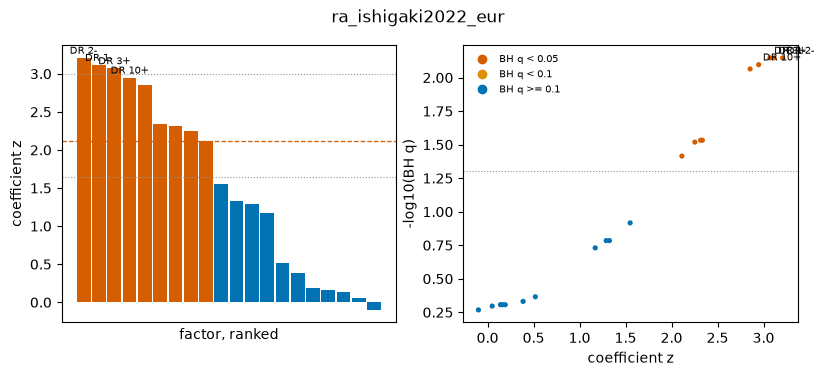

In [20]:
from scads_drvi.pl.enrichment import heritability_landscape

fig, _ = heritability_landscape(arm, trait="ra_ishigaki2022_eur", titles=embed.var["title"])
fig;

Both panels above rank the same factors, though -- the volcano's `-log10(q)` is a monotone, one-tailed function of the same z-score the bar chart already plots, so on a single trait the two panels are redundant. `latent_heatmap` below pairs that same heritability signal (an optional bar above the heatmap, with its own error bars and BH-significance colouring) with a genuinely different view instead -- which cells actually drive each enriched factor, split into its positive and negative direction by default (`directional=True`, matching `latent_umap_grid`'s own default -- every factor interpretability plot in this package shows split factors unless told not to) -- both directions' real S-LDSC z-scores are shown, not just the one this fit's top peaks happened to be scored under.

(`trait_concordance`, which compares this ranking against a second, independently-run trait, is deliberately not shown with real data here -- this tutorial runs one real S-LDSC sweep, against rheumatoid arthritis; a second real trait means a second multi-hour LDSC run. See its docstring/tests for a worked example.)

/allen/programs/celltypes/workgroups/hct/mike.cuoco/scads_drvi/.claude/worktrees/refactor-api/.venv/lib/python3.14/site-packages/scanpy/plotting/_utils.py:509: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[f"{value_to_plot}_colors"] = colors_list


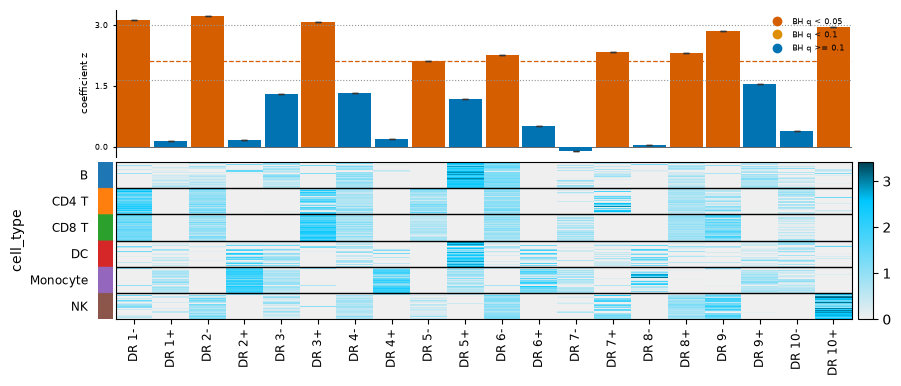

In [21]:
from scads_drvi.pl.factors import latent_heatmap

# Every dim x direction pair S-LDSC actually tested -- both directions now, keyed
# "{dim}+"/"{dim}-" the same way latent_heatmap's own directional split (the default,
# matching latent_umap_grid's own) names its columns, rather than picking one
# direction in advance the way a single-column-per-factor heatmap would have to.
signed = arm.assign(signed_dim=arm["dim"] + arm["direction"].map({"pos": "+", "neg": "-"}))
signed = signed.set_index("signed_dim")
embed_scored = embed[:, arm["dim"].unique()]

fig, _ = latent_heatmap(
    embed_scored, "cell_type",
    heritability=signed["Coefficient_z-score"], heritability_se=signed["Coefficient_std_error"],
    heritability_q=signed["fdr_q"],
)
fig;

## 4. Cell scores

A ReLU'd, direction-specific view of `embed.X` is the *only* place a positive/negative
split is ever materialized -- DRVI itself has none; `cs_from_z` folds each significant
factor's z-score-weighted loading into one per-cell score.


In [22]:
from scads_drvi.scores.cell import cs_from_z

# relu(X) -- the ONLY place a pos/neg split is ever materialized, derived on demand
loadings = pd.DataFrame(
    np.clip(embed.X, 0, None), index=embed.obs_names, columns=embed.var_names
)[keep]
# arm has one row per (factor, direction); cs_from_z needs one row per factor, so filter
# to the direction the loadings above are scoring -- "pos", to match.
pos_results = arm.query("direction == 'pos'")
scores = cs_from_z(loadings, pos_results, model="ra_ishigaki2022_eur", trait="ra_ishigaki2022_eur")

cells["score"] = scores.values.reindex(cells.index)
embed.obs["score"] = cells["score"]
scores.label, scores.null

('$CS_i$ (z-weighted loading sum)', 0.0)

In [23]:
from scads_drvi.scores.aggregate import summarize_by

summarize_by(scores.values, cells, by=["cell_type"], min_cells=10)


GroupStats(frame=  cell_type     n  n_scored       mean     median       std       sem  \
0         B  1003      1003   5.713595   5.365983  1.448398  0.045734   
1     CD4 T  3303      3303   7.768604   7.720228  1.251786  0.021781   
2     CD8 T  1587      1587   8.137359   8.162290  1.032867  0.025927   
3        DC   343       343   4.794778   4.586140  1.163705  0.062834   
4  Monocyte  3863      3863   3.755449   3.421775  1.309919  0.021076   
5        NK  1467      1467  11.305276  11.314944  1.639866  0.042815   

      ci_low    ci_high  
0   5.623958   5.803232  
1   7.725914   7.811294  
2   8.086543   8.188176  
3   4.671626   4.917931  
4   3.714141   3.796757  
5  11.221361  11.389191  , keys=('cell_type',), value='cs', min_cells=10, n_dropped=0)

Now that a per-cell score exists, the same heatmap above can carry it too --
`cell_scores` is just another optional `latent_heatmap` argument, drawn as a bar to
the right (one per `cell_type` group, its own standard error included) alongside the
heritability bar already on top. Same figure as Section 3's, richer than the table
above.

/allen/programs/celltypes/workgroups/hct/mike.cuoco/scads_drvi/.claude/worktrees/refactor-api/.venv/lib/python3.14/site-packages/scanpy/plotting/_utils.py:509: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[f"{value_to_plot}_colors"] = colors_list


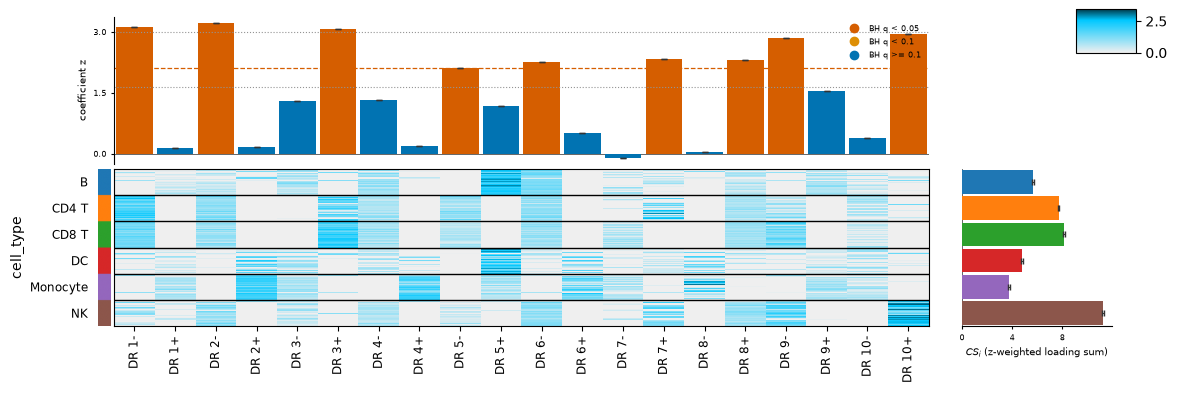

In [24]:
fig, _ = latent_heatmap(
    embed_scored, "cell_type",
    heritability=signed["Coefficient_z-score"], heritability_se=signed["Coefficient_std_error"],
    heritability_q=signed["fdr_q"], cell_scores=embed.obs["score"], cell_score_label=scores.label,
)
fig;

`cell_score_agg="sum"` instead of the default `"mean"` shows each group's raw,
non-normalised total instead of its per-cell average -- "non-normalised cell weights":
a large, modestly-scoring group can outweigh a small, high-scoring one here, the
opposite emphasis from the per-cell average above.

/allen/programs/celltypes/workgroups/hct/mike.cuoco/scads_drvi/.claude/worktrees/refactor-api/.venv/lib/python3.14/site-packages/scanpy/plotting/_utils.py:509: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[f"{value_to_plot}_colors"] = colors_list


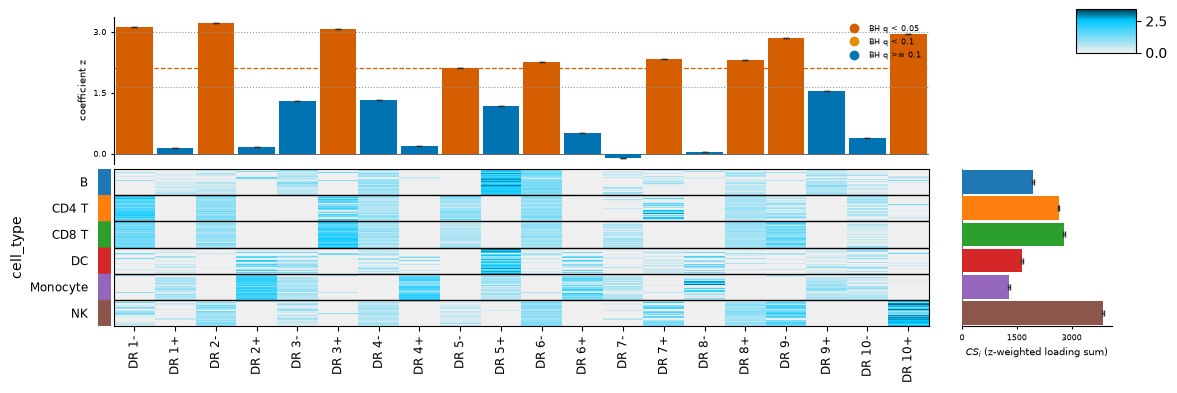

In [25]:
fig, _ = latent_heatmap(
    embed_scored, "cell_type",
    heritability=signed["Coefficient_z-score"], heritability_se=signed["Coefficient_std_error"],
    heritability_q=signed["fdr_q"], cell_scores=embed.obs["score"], cell_score_label=scores.label,
    cell_score_agg="sum",
)
fig;

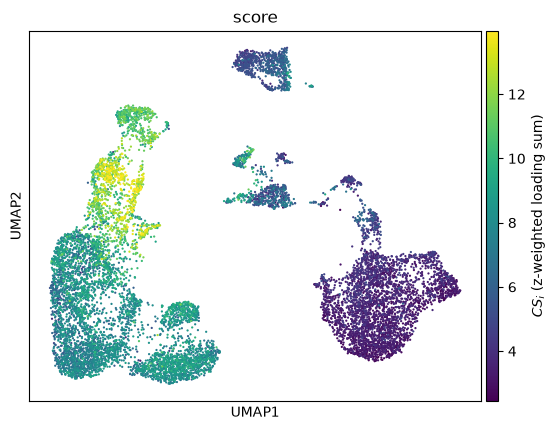

In [26]:
# A continuous embedding scatter is a scanpy call too -- vmin/vmax as scanpy's
# own percentile strings, matching scads_drvi.pl.color.ROBUST_LIMITS.
fig = sc.pl.embedding(
    embed, basis="umap", color="score", vmin="p1", vmax="p99.5",
    show=False, return_fig=True,
)
fig.axes[-1].set_ylabel(scores.label)
fig;

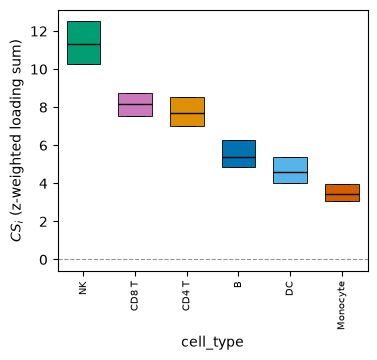

In [27]:
from scads_drvi.pl.enrichment import score_by_group
from scads_drvi.pl.frugal import box_stats

box_stats_frame = box_stats(cells["score"], cells["cell_type"].astype(str), min_n=10)
fig, _ = score_by_group(
    box_stats_frame, group_label="cell_type", value_label=scores.label, null=scores.null,
)
fig;

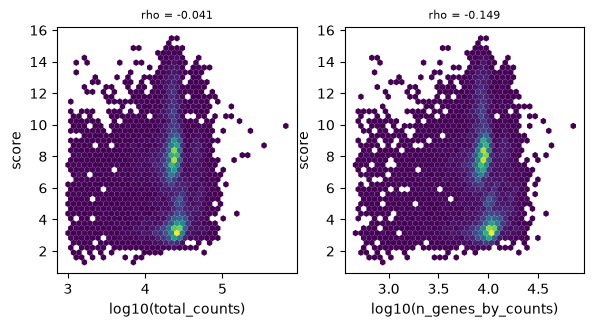

In [28]:
from scads_drvi.pl.enrichment import covariate_audit

# Does the score itself just track sequencing depth?
fig, _ = covariate_audit(
    cells, value="score", covariates=["total_counts", "n_genes_by_counts"],
    log_x=["total_counts", "n_genes_by_counts"],
)
fig;

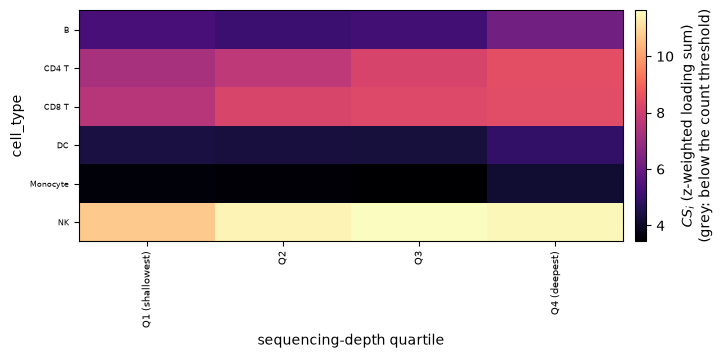

In [29]:
from scads_drvi.pl.enrichment import grouped_landscape
from scads_drvi.scores.aggregate import group_matrix

# A second, real grouping derived from the real per-cell depth -- not a second
# categorical obs column this dataset happens to carry.
cells["depth_quartile"] = pd.qcut(
    cells["total_counts"], 4, labels=["Q1 (shallowest)", "Q2", "Q3", "Q4 (deepest)"]
)
means, counts = group_matrix(
    scores.values, cells, index="cell_type", columns="depth_quartile", min_cells=10,
)
fig, _ = grouped_landscape(
    means, counts, row_label="cell_type", column_label="sequencing-depth quartile",
    value_label=scores.label,
)
fig;

## 5. Annotate: real peak coordinates against a real motif-score database

`scads-drvi` does not own a peak↔motif-score overlap builder any more than it owns
peak→SNP annotation (Section 3) -- both are caller-supplied, same as the peaks
themselves. `annotate.motif` scores a (factor, motif) pair by the weighted
expectation of the motif's score under the factor's peak weights, calibrated
against an **exact, never-sampled** permutation null within GC × width-matched
strata -- see the module's own docstring for why weighted beats the binarized,
top-fraction route DEM-style tools use.

A factor's real per-peak loadings need the same real
`model.get_effect_of_splits_within_distribution` call Section 3 already runs to
build its peak→SNP annotations, and the real database below (aertslab's public
SCREEN cisTarget-style resource, hg38, ~14 GB) needs real memory to stream --
several GB per column slab at this database's real motif count -- and a few
minutes, not something to run casually inside an interactive kernel. Shown as the
real call, **not executed here**, followed by what running it for real under a
scheduler actually measured.

In [30]:
# NOT EXECUTED HERE (needs the real production database and a scheduler-sized
# allocation, not an interactive kernel -- see annotate.resources and
# tests/test_motif_pbmc.py's real-database test, which runs exactly this) --
# the real call that produced the numbers in the markdown cell below.
#
# from scads_drvi.annotate.motif import (
#     build_region_map, gc_width_strata, read_score_db_regions, regionise,
#     weighted_motif_enrichment,
# )
# from scads_drvi.annotate.resources import ensure_screen_database
#
# # Positive-direction peak effects for this fit's kept factors -- Section 3's
# # own call, reused rather than recomputed.
# effect = model.get_effect_of_splits_within_distribution(
#     atac, aggregations="max", directional=True
# )
# kept_factors = kept_dims(fmap)
# W = pd.DataFrame(effect["max"][0].T, index=atac.var_names, columns=embed.var_names)
# W = W[kept_factors].to_numpy().T
#
# db_path = ensure_screen_database(allow_download=True)   # ~14 GB, hg38 SCREEN v10
# db_region_names = read_score_db_regions(db_path)
# used_cols, peak_rows, region_names = build_region_map(atac.var_names, db_region_names)
# Wr = regionise(W, peak_rows)
#
# keep, strata_ix, n_strata = gc_width_strata(region_names, "/path/to/hg38.fa")
# used_cols, Wr = used_cols[keep], Wr[:, keep]
# region_names = [r for r, k in zip(region_names, keep) if k]
#
# rows, meta = weighted_motif_enrichment(
#     Wr, kept_factors, used_cols, region_names, strata_ix, n_strata, db_path,
#     check_invariance=True,
# )
# embed.uns.setdefault("annotate", {})["motif"] = {"results": rows, "meta": meta}
# embed.write_h5ad("data/pbmc_result.h5ad")

Run for real under SLURM (8 cpus, 64G) against exactly this database and this
sample's real ATAC peaks: **2,961** of them matched a real SCREEN region (of
1,837,304 total, 0.2% -- SCREEN is genome-wide, most of it far from any one
sample's open chromatin), scored against **5,876** real motifs, in 165s of
streaming, with the scale-invariance property (`check_invariance=True`) intact
to 4.33e-07. The rest of this section reproduces the same pipeline, mechanically
identical, against a small stand-in database built below -- so it runs here,
inline, with no 14 GB download and no scheduler.

In [31]:
import re
from pathlib import Path

import numpy as np
import scanpy as sc

# The same real ATAC peaks Section 1 builds, read independently here so this
# section stands alone and needs no GPU-trained model -- from the file Section 0
# already downloaded.
matrix_path = Path("data") / "pbmc_multiome_filtered_feature_bc_matrix.h5"
raw = sc.read_10x_h5(matrix_path, gex_only=False)
raw.var_names_make_unique()
PEAK_RE = re.compile(r"^chr([1-9]|1[0-9]|2[0-2]|X|Y):\d+-\d+$")
real_peaks = [
    p for p in raw.var_names[raw.var["feature_types"] == "Peaks"] if PEAK_RE.match(p)
]

rng = np.random.default_rng(0)
peaks = sorted(rng.choice(real_peaks, size=min(2000, len(real_peaks)), replace=False))
print(f"{len(real_peaks):,} real ATAC peaks total, {len(peaks):,} sampled for this demo")

/home/mike.cuoco/micromamba/envs/scads-drvi-test/lib/python3.12/site-packages/scanpy/readwrite.py:322: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  return AnnData(matrix, obs=obs_dict, var=var_dict)


143,836 real ATAC peaks total, 2,000 sampled for this demo


No public score database is small, and this sample's own DRVI factor loadings need
the trained model from Section 2 in memory. So: a small database built over
*translated* copies of these same real peak coordinates (so `build_region_map` does
real overlap arithmetic, not a trivial identity join), and peak **width** as a
"pseudo-factor" standing in for a DRVI factor's loadings -- a real, non-random
per-peak quantity, exactly `tests/test_motif_pbmc.py`'s approach. The mechanics
under test -- overlap mapping, regionising, stratification, the exact permutation
null -- don't care where the weights came from.

In [32]:
import pyarrow as pa
import pyarrow.feather as pf

from scads_drvi.annotate.motif import (
    build_region_map,
    covariate_strata,
    regionise,
    weighted_motif_enrichment,
)
from scads_drvi.enrich.config import parse_peaks

coords = parse_peaks(peaks)
widths = (coords["end"] - coords["start"]).to_numpy()
jitter = rng.integers(-49, 50, size=len(peaks))
starts = np.maximum(0, coords["start"].to_numpy() + jitter)
db_regions = [f"{c}:{s}-{s + w}" for c, s, w in zip(coords["chrom"], starts, widths, strict=True)]

motif_ids = [f"motif_{i}" for i in range(30)]
scores = rng.lognormal(0, 1, size=(len(motif_ids), len(db_regions))).astype("float32")
scores[rng.random(scores.shape) < 0.5] = 0.0
db_path = Path("data") / "demo_scores.feather"
pf.write_feather(
    pa.table({**{r: scores[:, j] for j, r in enumerate(db_regions)}, "motifs": motif_ids}),
    db_path,
)

W = widths.astype(np.float64)[None, :]
used_cols, peak_rows, region_names = build_region_map(peaks, db_regions, fraction_overlap=0.1)
Wr = regionise(W, peak_rows)

region_width = (parse_peaks(region_names)["end"] - parse_peaks(region_names)["start"]).to_numpy(
    dtype=np.float64
)
keep, strata_ix, n_strata = covariate_strata([region_width], n_bins=4)
used_cols, Wr = used_cols[keep], Wr[:, keep]
region_names = [r for r, k in zip(region_names, keep, strict=True) if k]

rows, meta = weighted_motif_enrichment(
    Wr, ["width_pseudo_factor"], used_cols, region_names, strata_ix, n_strata, db_path,
    check_invariance=True,
)
print(meta)
rows.sort_values("nes", ascending=False).head()

/tmp/ipykernel_1192706/1445731117.py:19: FutureWarning: pyarrow.feather.write_feather is deprecated as of 24.0.0. Use pyarrow.ipc.new_file() / RecordBatchFileWriter instead. Feather V2 is the Arrow IPC file format.
  pf.write_feather(


>> building region overlap map...


>> matched 2,000 / 2,000 db regions (100.0%), covering 2,000 / 2,000 peaks (100.0%)


>> 4 strata over 2,000 regions (median 497 regions/stratum)


/allen/programs/celltypes/workgroups/hct/mike.cuoco/scads_drvi/.claude/worktrees/annotate-motif-weighted/src/scads_drvi/annotate/motif.py:354: FutureWarning: pyarrow.feather.read_table is deprecated as of 24.0.0. Use pyarrow.ipc.open_file() / RecordBatchFileReader instead. Feather V2 is the Arrow IPC file format.
  tbl = pf.read_table(db_path, columns=list(range(lo, hi)),
>>   slab [0,2,000) -> 2,000 used (2,000 total, 0s)


>> scale-invariance check passed (max |delta| = 5.41e-07)


/allen/programs/celltypes/workgroups/hct/mike.cuoco/scads_drvi/.claude/worktrees/annotate-motif-weighted/src/scads_drvi/annotate/motif.py:311: FutureWarning: pyarrow.feather.read_table is deprecated as of 24.0.0. Use pyarrow.ipc.open_file() / RecordBatchFileReader instead. Feather V2 is the Arrow IPC file format.
  return pf.read_table(db_path, columns=[len(names)]).column(0).to_pylist()


>> scored 30 (factor, motif) pairs in 0s


{'n_regions': 2000, 'n_factors': 1, 'n_motifs': 30, 'n_strata': 4, 'elapsed_s': 0.2}


,factor,motif_id,weighted_score,nes,nes_unstratified,n_regions
0,width_pseudo_factor,motif_5,0.862016,1.602409,0.116537,2000
1,width_pseudo_factor,motif_1,0.768692,1.453131,1.089868,2000
2,width_pseudo_factor,motif_16,0.790532,1.222432,0.593181,2000
3,width_pseudo_factor,motif_12,0.921552,0.992346,2.202194,2000
4,width_pseudo_factor,motif_15,0.853299,0.809809,-0.190052,2000


Storage matches every other stage: attach the result into `uns` and write the same
h5ad, no wrapper --

```python
embed.uns.setdefault("annotate", {})["motif"] = {"results": rows, "meta": meta}
embed.write_h5ad("data/pbmc_result.h5ad")
```

Both the exact statistic (`stratified_nes`) and the streaming machinery around it
(`build_region_map`, `stream_accumulate`) run identically whether the database is
this notebook's small stand-in or the real 14 GB one above -- see
`tests/test_motif.py` (closed-form-vs-sampled-permutation, scale invariance, a
planted-confounder test) and `tests/test_motif_pbmc.py` (this same pipeline, on
real peak coordinates, against both databases, plus the `write_h5ad`/`read_h5ad`
round-trip above).

## Where DRVI's own tools still take over

Every `pl.*` figure this package draws has been shown above: `latent_umap_grid` (a per-dimension embedding grid; a plain categorical or continuous embedding scatter is just `sc.pl.embedding` directly -- see above), `factor_correlation`/`factor_distributions`/`covariate_association`/`latent_dimension_stats`/`latent_heatmap` (factor diagnostics -- `latent_heatmap` itself optionally draws a per-dimension heritability bar above it and a per-group cell-score bar to its right, both with error bars, rather than a second `latent_heatmap_with_heritability`-style function), and `heritability_landscape`/`covariate_audit`/`score_by_group`/`grouped_landscape` (enrichment and scores) -- `latent_umap_grid`/`latent_dimension_stats`/`latent_heatmap` ported to match DRVI's own colours and mechanics exactly, wrapping `scanpy.pl.embedding` directly where an embedding is involved, needing no `drvi-py` install. (`trait_concordance` is the one figure not shown against real data here -- it compares two independently-run traits, and this tutorial only runs one.)

`latent_umap_grid` and `latent_heatmap` both default to `directional=True` -- every factor interpretability plot in this package shows split factors (each dimension's own +/- columns or panels) unless told not to (`directional=False`). `latent_heatmap`'s `cell_score_agg` also takes `"sum"` alongside the default `"mean"`/`"median"`, for a group's raw, non-normalised total rather than its per-cell average -- both shown in Section 4 above.

What genuinely still has no in-house equivalent is DRVI's own model-side interpretability: the model's `get_effect_of_splits_within_distribution`/`_out_of_distribution` (used above to rank each factor's top peaks) and `calculate_interpretability_scores`. `scads-drvi` wraps none of these a second time -- see the [DRVI docs](https://drvi.readthedocs.io/).